# Linear Gaussian Systems: Inferring Physiological State from Derived Health Metrics

## Real-World Scenario: Cardiovascular Health Assessment

A sports medicine clinic monitors athletes' cardiovascular fitness using a wearable device. The device cannot directly measure the underlying physiological state, but instead measures **derived metrics** that are linear combinations of the true physiological variables.

**Latent state** $\mathbf{z} \in \mathbb{R}^3$: The athlete's true physiological variables:
- $z_1$: Resting heart rate (bpm)
- $z_2$: Systolic blood pressure (mmHg)
- $z_3$: Diastolic blood pressure (mmHg)

**Observations** $\mathbf{y} \in \mathbb{R}^5$: The wearable measures derived quantities:
- $y_1$: **Pulse Pressure** = Systolic - Diastolic = $z_2 - z_3$
- $y_2$: **Mean Arterial Pressure (MAP)** = Diastolic + ⅓(Systolic - Diastolic) = $\frac{1}{3}z_2 + \frac{2}{3}z_3$
- $y_3$: **Rate-Pressure Product (RPP)** = HR × Systolic / 100 = $0.01 \cdot z_1 \cdot z_2$ (linearized around operating point)
- $y_4$: **Cardiac Output Index** ≈ $0.5 z_1 - 0.1 z_3$ (simplified model)
- $y_5$: **Vascular Resistance Proxy** ≈ $0.8 z_2 + 0.3 z_3 - 0.2 z_1$

Our goal: Infer the true physiological state from these noisy derived measurements using **Bayes rule for Gaussians**.

## Mathematical Framework (Chapter 3.3.1)

### Linear Gaussian System with Non-Trivial W

**Prior over physiological state:**
$$p(\mathbf{z}) = \mathcal{N}(\mathbf{z} | \boldsymbol{\mu}_z, \boldsymbol{\Sigma}_z)$$

**Likelihood (measurement model):**
$$p(\mathbf{y}|\mathbf{z}) = \mathcal{N}(\mathbf{y} | \mathbf{W}\mathbf{z} + \mathbf{b}, \boldsymbol{\Sigma}_y)$$

where the **key difference** from simple measurement is that $\mathbf{W}$ is now a **non-trivial mixing matrix**:

$$\mathbf{W} = \begin{pmatrix}
0 & 1 & -1 \\
0 & 1/3 & 2/3 \\
1.2 & 0.7 & 0 \\
0.5 & 0 & -0.1 \\
-0.2 & 0.8 & 0.3
\end{pmatrix}$$

Each row of $\mathbf{W}$ defines a **linear combination** of the latent variables!

### Bayes Rule for Gaussians (Eq. 3.37)

**Posterior:**
$$p(\mathbf{z}|\mathbf{y}) = \mathcal{N}(\mathbf{z} | \boldsymbol{\mu}_{z|y}, \boldsymbol{\Sigma}_{z|y})$$

$$\boldsymbol{\Sigma}_{z|y}^{-1} = \boldsymbol{\Sigma}_z^{-1} + \mathbf{W}^T \boldsymbol{\Sigma}_y^{-1} \mathbf{W}$$

$$\boldsymbol{\mu}_{z|y} = \boldsymbol{\Sigma}_{z|y} \left[ \mathbf{W}^T \boldsymbol{\Sigma}_y^{-1} (\mathbf{y} - \mathbf{b}) + \boldsymbol{\Sigma}_z^{-1} \boldsymbol{\mu}_z \right]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, norm
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

# Set up nice plotting
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 12

## 1. Define the Physiological State Space

In [2]:
# =============================================================================
# LATENT SPACE (3D): True physiological state
# =============================================================================
L = 3  # Latent dimension: [heart_rate, systolic_bp, diastolic_bp]

# True (unknown) physiological state of a well-trained athlete
z_true = np.array([58.0,    # Resting HR: 58 bpm (athletic bradycardia)
                   118.0,   # Systolic BP: 118 mmHg
                   72.0])   # Diastolic BP: 72 mmHg

# Prior belief: Based on athlete's baseline measurements from training camp
# Athletes typically have lower resting HR and BP
mu_z = np.array([60.0,    # Expected resting HR
                 120.0,   # Expected systolic
                 75.0])   # Expected diastolic

# Prior covariance: Reflects natural variability in physiological state
# HR varies more day-to-day, BP values are correlated
Sigma_z = np.array([
    [36.0,  5.0,  3.0],   # HR variance = 36 (SD = 6 bpm)
    [ 5.0, 64.0, 30.0],   # Systolic variance = 64 (SD = 8 mmHg)
    [ 3.0, 30.0, 25.0]    # Diastolic variance = 25 (SD = 5 mmHg)
])  # Note: systolic and diastolic are positively correlated

print("=" * 65)
print("ATHLETE PROFILE - True Physiological State (Unknown)")
print("=" * 65)
print(f"True state z* = [HR: {z_true[0]:.0f} bpm, Sys: {z_true[1]:.0f} mmHg, Dia: {z_true[2]:.0f} mmHg]")
print(f"\nDerived (true) values:")
print(f"  Pulse Pressure: {z_true[1] - z_true[2]:.0f} mmHg")
print(f"  Mean Arterial Pressure: {z_true[2] + (z_true[1] - z_true[2])/3:.1f} mmHg")
print(f"\nPrior from training baseline:")
print(f"  Mean μ_z = [HR: {mu_z[0]:.0f}, Sys: {mu_z[1]:.0f}, Dia: {mu_z[2]:.0f}]")
print(f"  Std dev = [HR: {np.sqrt(Sigma_z[0,0]):.1f}, Sys: {np.sqrt(Sigma_z[1,1]):.1f}, Dia: {np.sqrt(Sigma_z[2,2]):.1f}]")

ATHLETE PROFILE - True Physiological State (Unknown)
True state z* = [HR: 58 bpm, Sys: 118 mmHg, Dia: 72 mmHg]

Derived (true) values:
  Pulse Pressure: 46 mmHg
  Mean Arterial Pressure: 87.3 mmHg

Prior from training baseline:
  Mean μ_z = [HR: 60, Sys: 120, Dia: 75]
  Std dev = [HR: 6.0, Sys: 8.0, Dia: 5.0]


## 2. Define the Non-Trivial Observation Model

In [3]:
# =============================================================================
# OBSERVATION SPACE (5D): Derived health metrics
# =============================================================================
# The wearable device computes these derived metrics from sensors
# Each observation is a LINEAR COMBINATION of the latent physiological state

D = 5  # Observation dimension

# W matrix: NON-TRIVIAL linear combinations!
# Each row represents how one observation depends on the latent variables
# Columns: [HR, Systolic, Diastolic]
W = np.array([
    # y1: Pulse Pressure = Systolic - Diastolic
    [0.0,  1.0, -1.0],
    
    # y2: Mean Arterial Pressure = (1/3)*Systolic + (2/3)*Diastolic
    [0.0,  1/3,  2/3],
    
    # y3: Rate-Pressure Product (linearized) ≈ 0.012*HR*Sys
    # Linearized around (HR=60, Sys=120): RPP ≈ 86.4 + 1.2*(HR-60) + 0.72*(Sys-120)
    # Simplified: y3 ≈ 1.2*HR + 0.72*Sys (with bias term)
    [1.2,  0.72, 0.0],
    
    # y4: Cardiac Output Index (simplified model)
    # Higher HR increases output, higher diastolic (resistance) decreases it
    [0.5,  0.0, -0.1],
    
    # y5: Vascular Resistance Proxy
    # Depends mainly on BP, inversely on HR (higher HR = lower resistance)
    [-0.2, 0.8,  0.3]
])

# b vector: Calibration offsets/bias terms
b = np.array([
    0.0,      # Pulse pressure: no offset
    0.0,      # MAP: no offset
    -86.4,    # RPP linearization offset
    25.0,     # Cardiac output baseline
    10.0      # Vascular resistance baseline
])

# Observation noise covariance
# Different metrics have different measurement precisions
Sigma_y = np.diag([
    9.0,    # Pulse pressure: SD = 3 mmHg
    4.0,    # MAP: SD = 2 mmHg (more stable measurement)
    25.0,   # RPP: SD = 5 (composite metric, more noise)
    4.0,    # Cardiac output index: SD = 2
    16.0    # Vascular resistance: SD = 4 (indirect measurement)
])

print("\n" + "=" * 65)
print("OBSERVATION MODEL - Derived Health Metrics")
print("=" * 65)
print("\nW matrix (each row is a linear combination of [HR, Sys, Dia]):")
print("-" * 50)
metric_names = [
    "Pulse Pressure",
    "Mean Arterial Pressure",
    "Rate-Pressure Product",
    "Cardiac Output Index",
    "Vascular Resistance"
]
for i, (name, row) in enumerate(zip(metric_names, W)):
    formula = f"{row[0]:+.2f}·HR {row[1]:+.2f}·Sys {row[2]:+.2f}·Dia"
    print(f"y{i+1} ({name:24s}) = {formula}")
print("-" * 50)
print("\nThis W matrix is FULL RANK - all observations provide unique information!")


OBSERVATION MODEL - Derived Health Metrics

W matrix (each row is a linear combination of [HR, Sys, Dia]):
--------------------------------------------------
y1 (Pulse Pressure          ) = +0.00·HR +1.00·Sys -1.00·Dia
y2 (Mean Arterial Pressure  ) = +0.00·HR +0.33·Sys +0.67·Dia
y3 (Rate-Pressure Product   ) = +1.20·HR +0.72·Sys +0.00·Dia
y4 (Cardiac Output Index    ) = +0.50·HR +0.00·Sys -0.10·Dia
y5 (Vascular Resistance     ) = -0.20·HR +0.80·Sys +0.30·Dia
--------------------------------------------------

This W matrix is FULL RANK - all observations provide unique information!


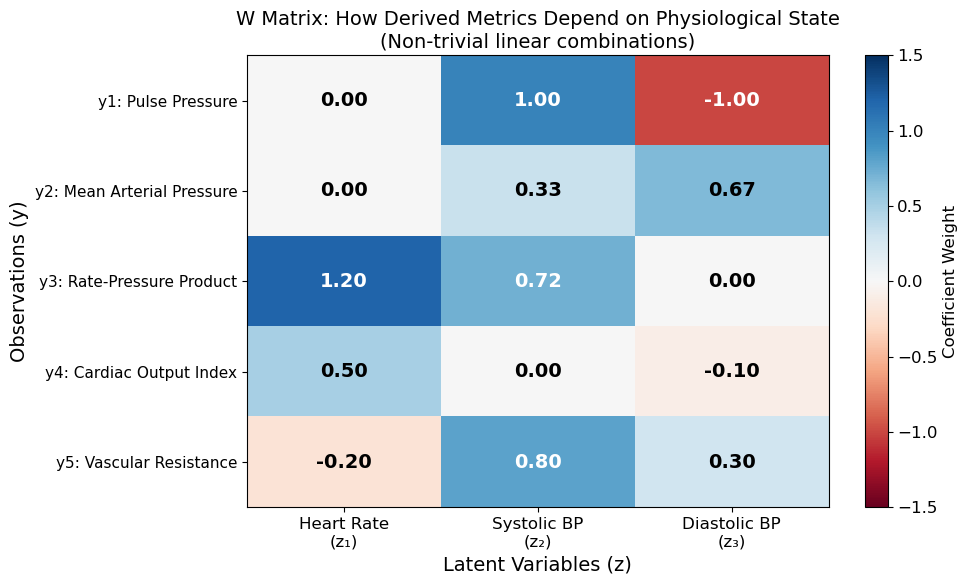

In [4]:
# Visualize the W matrix structure
fig, ax = plt.subplots(figsize=(10, 6))

im = ax.imshow(W, cmap='RdBu', aspect='auto', vmin=-1.5, vmax=1.5)

# Add text annotations
for i in range(D):
    for j in range(L):
        text = f"{W[i,j]:.2f}"
        color = 'white' if abs(W[i,j]) > 0.7 else 'black'
        ax.text(j, i, text, ha='center', va='center', fontsize=14, color=color, fontweight='bold')

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Heart Rate\n(z₁)', 'Systolic BP\n(z₂)', 'Diastolic BP\n(z₃)'], fontsize=12)
ax.set_yticks(range(D))
ax.set_yticklabels([f'y{i+1}: {name}' for i, name in enumerate(metric_names)], fontsize=11)
ax.set_xlabel('Latent Variables (z)', fontsize=14)
ax.set_ylabel('Observations (y)', fontsize=14)
ax.set_title('W Matrix: How Derived Metrics Depend on Physiological State\n(Non-trivial linear combinations)', fontsize=14)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Coefficient Weight', fontsize=12)

plt.tight_layout()
plt.show()

## 3. Generate Noisy Observations

In [5]:
# Generate noisy measurements from true physiological state
# y = Wz + b + noise

# Expected observations (without noise)
y_expected = W @ z_true + b

# Actual noisy observations from the wearable
noise = np.random.multivariate_normal(np.zeros(D), Sigma_y)
y_observed = y_expected + noise

print("=" * 65)
print("WEARABLE DEVICE READINGS")
print("=" * 65)
print(f"\nTrue physiological state: HR={z_true[0]:.0f}, Sys={z_true[1]:.0f}, Dia={z_true[2]:.0f}")
print("\n" + "-" * 55)
print(f"{'Metric':<28} {'Expected':>10} {'Observed':>10} {'Noise':>8}")
print("-" * 55)
for i, name in enumerate(metric_names):
    print(f"{name:<28} {y_expected[i]:>10.1f} {y_observed[i]:>10.1f} {noise[i]:>+8.1f}")
print("-" * 55)
print("\nNote: We observe ONLY the 'Observed' column - not the true state!")

WEARABLE DEVICE READINGS

True physiological state: HR=58, Sys=118, Dia=72

-------------------------------------------------------
Metric                         Expected   Observed    Noise
-------------------------------------------------------
Pulse Pressure                     46.0       47.9     +1.9
Mean Arterial Pressure             87.3       86.9     -0.5
Rate-Pressure Product              68.2       70.6     +2.5
Cardiac Output Index               46.8       49.8     +3.0
Vascular Resistance               114.4      113.8     -0.6
-------------------------------------------------------

Note: We observe ONLY the 'Observed' column - not the true state!


## 4. Apply Bayes Rule for Gaussians (Eq. 3.37)

In [6]:
def bayes_rule_gaussian(y, mu_z, Sigma_z, W, b, Sigma_y):
    """
    Compute posterior p(z|y) using Bayes rule for Gaussians.
    
    Prior: p(z) = N(z | mu_z, Sigma_z)
    Likelihood: p(y|z) = N(y | Wz + b, Sigma_y)
    Posterior: p(z|y) = N(z | mu_z|y, Sigma_z|y)
    
    From Equation 3.37:
    Σ_{z|y}^{-1} = Σ_z^{-1} + W^T Σ_y^{-1} W
    μ_{z|y} = Σ_{z|y} [W^T Σ_y^{-1} (y - b) + Σ_z^{-1} μ_z]
    """
    # Compute precision matrices (inverse of covariance)
    Sigma_z_inv = np.linalg.inv(Sigma_z)
    Sigma_y_inv = np.linalg.inv(Sigma_y)
    
    # Posterior precision (Eq. 3.37, first equation)
    Sigma_post_inv = Sigma_z_inv + W.T @ Sigma_y_inv @ W
    
    # Posterior covariance
    Sigma_post = np.linalg.inv(Sigma_post_inv)
    
    # Posterior mean (Eq. 3.37, second equation)
    mu_post = Sigma_post @ (W.T @ Sigma_y_inv @ (y - b) + Sigma_z_inv @ mu_z)
    
    return mu_post, Sigma_post

# Compute posterior
mu_post, Sigma_post = bayes_rule_gaussian(y_observed, mu_z, Sigma_z, W, b, Sigma_y)

print("=" * 65)
print("BAYESIAN INFERENCE - Recovered Physiological State")
print("=" * 65)
print(f"\n{'Variable':<20} {'True':>10} {'Prior':>10} {'Posterior':>10} {'Post SD':>10}")
print("-" * 60)
var_names = ['Heart Rate (bpm)', 'Systolic (mmHg)', 'Diastolic (mmHg)']
for i, name in enumerate(var_names):
    print(f"{name:<20} {z_true[i]:>10.1f} {mu_z[i]:>10.1f} {mu_post[i]:>10.1f} {np.sqrt(Sigma_post[i,i]):>10.2f}")
print("-" * 60)

error = np.linalg.norm(mu_post - z_true)
print(f"\nEstimation error (Euclidean): {error:.2f}")
print(f"\nThe Bayesian method successfully recovered the physiological state")
print(f"from derived metrics that are linear combinations of the true variables!")

BAYESIAN INFERENCE - Recovered Physiological State

Variable                   True      Prior  Posterior    Post SD
------------------------------------------------------------
Heart Rate (bpm)           58.0       60.0       61.6       2.60
Systolic (mmHg)           118.0      120.0      118.2       2.17
Diastolic (mmHg)           72.0       75.0       71.6       1.85
------------------------------------------------------------

Estimation error (Euclidean): 3.63

The Bayesian method successfully recovered the physiological state
from derived metrics that are linear combinations of the true variables!


## 5. Visualize Inference in Latent Space

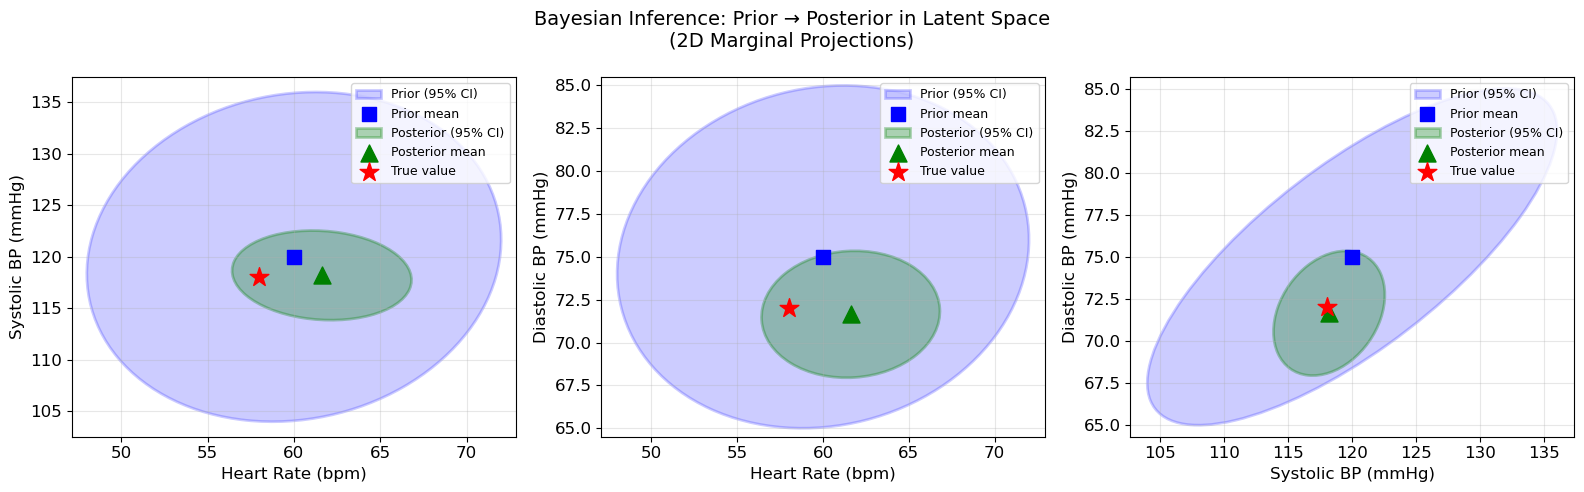

In [7]:
from matplotlib.patches import Ellipse

def plot_confidence_ellipse(ax, mean, cov, n_std=2.0, **kwargs):
    """Plot a 2D confidence ellipse."""
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)
    return ellipse

# Create 2D projections of the 3D distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

projections = [
    (0, 1, 'Heart Rate (bpm)', 'Systolic BP (mmHg)'),
    (0, 2, 'Heart Rate (bpm)', 'Diastolic BP (mmHg)'),
    (1, 2, 'Systolic BP (mmHg)', 'Diastolic BP (mmHg)')
]

for ax, (i, j, xlabel, ylabel) in zip(axes, projections):
    # Extract 2D marginals
    idx = [i, j]
    mu_z_2d = mu_z[idx]
    Sigma_z_2d = Sigma_z[np.ix_(idx, idx)]
    mu_post_2d = mu_post[idx]
    Sigma_post_2d = Sigma_post[np.ix_(idx, idx)]
    z_true_2d = z_true[idx]
    
    # Plot prior
    plot_confidence_ellipse(ax, mu_z_2d, Sigma_z_2d, n_std=2,
                           facecolor='blue', alpha=0.2, edgecolor='blue',
                           linewidth=2, label='Prior (95% CI)')
    ax.scatter(*mu_z_2d, c='blue', s=100, marker='s', zorder=5, label='Prior mean')
    
    # Plot posterior
    plot_confidence_ellipse(ax, mu_post_2d, Sigma_post_2d, n_std=2,
                           facecolor='green', alpha=0.3, edgecolor='green',
                           linewidth=2, label='Posterior (95% CI)')
    ax.scatter(*mu_post_2d, c='green', s=150, marker='^', zorder=6, label='Posterior mean')
    
    # Plot true value
    ax.scatter(*z_true_2d, c='red', s=200, marker='*', zorder=10, label='True value')
    
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle('Bayesian Inference: Prior → Posterior in Latent Space\n(2D Marginal Projections)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. The Key Role of W: Information Flow Analysis

In [8]:
# Analyze how the W matrix transforms information
Sigma_y_inv = np.linalg.inv(Sigma_y)
data_precision = W.T @ Sigma_y_inv @ W
Sigma_z_inv = np.linalg.inv(Sigma_z)

print("=" * 65)
print("INFORMATION FLOW ANALYSIS")
print("=" * 65)

print("\n1. W^T Σ_y^{-1} W: How observations inform the latent state")
print("-" * 50)
print("This matrix shows how much precision (information) each latent")
print("variable gains from the observations:\n")
print(f"         HR        Sys       Dia")
for i, name in enumerate(['HR', 'Sys', 'Dia']):
    print(f"{name:4s}  {data_precision[i,0]:8.4f}  {data_precision[i,1]:8.4f}  {data_precision[i,2]:8.4f}")

print("\n2. Diagonal elements = direct information gain:")
print(f"   HR gains:  {data_precision[0,0]:.4f} precision")
print(f"   Sys gains: {data_precision[1,1]:.4f} precision")
print(f"   Dia gains: {data_precision[2,2]:.4f} precision")

print("\n3. Off-diagonal = how observations couple the variables:")
print(f"   HR-Sys coupling: {data_precision[0,1]:.4f}")
print(f"   HR-Dia coupling: {data_precision[0,2]:.4f}")
print(f"   Sys-Dia coupling: {data_precision[1,2]:.4f}")

INFORMATION FLOW ANALYSIS

1. W^T Σ_y^{-1} W: How observations inform the latent state
--------------------------------------------------
This matrix shows how much precision (information) each latent
variable gains from the observations:

         HR        Sys       Dia
HR      0.1226    0.0246   -0.0163
Sys     0.0246    0.1996   -0.0406
Dia    -0.0163   -0.0406    0.2303

2. Diagonal elements = direct information gain:
   HR gains:  0.1226 precision
   Sys gains: 0.1996 precision
   Dia gains: 0.2303 precision

3. Off-diagonal = how observations couple the variables:
   HR-Sys coupling: 0.0246
   HR-Dia coupling: -0.0163
   Sys-Dia coupling: -0.0406


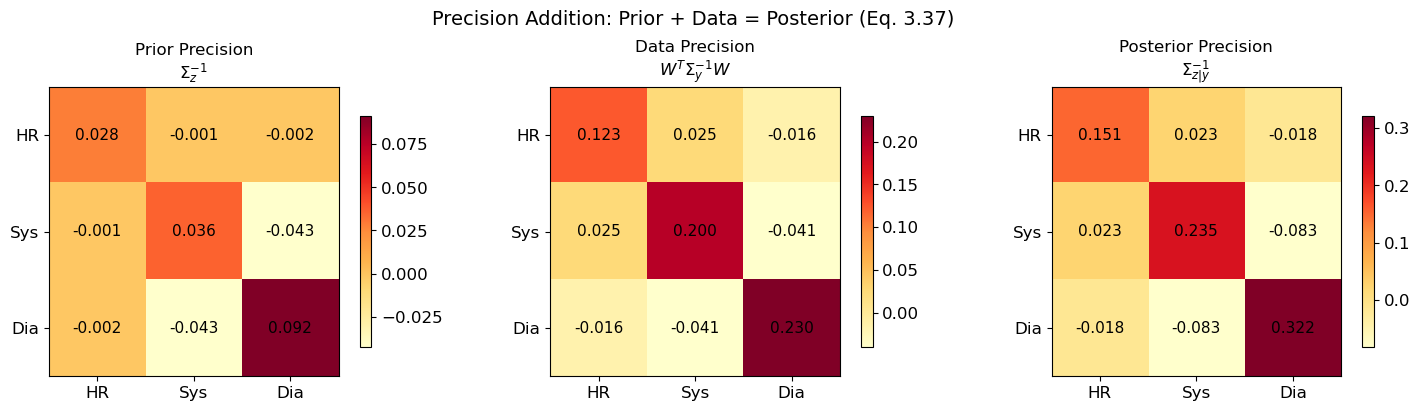

In [9]:
# Visualize precision matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

matrices = [
    (Sigma_z_inv, 'Prior Precision\n$\\Sigma_z^{-1}$'),
    (data_precision, 'Data Precision\n$W^T \\Sigma_y^{-1} W$'),
    (Sigma_z_inv + data_precision, 'Posterior Precision\n$\\Sigma_{z|y}^{-1}$')
]

labels = ['HR', 'Sys', 'Dia']

for ax, (mat, title) in zip(axes, matrices):
    im = ax.imshow(mat, cmap='YlOrRd', aspect='equal')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{mat[i,j]:.3f}", ha='center', va='center', fontsize=11)
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1, 2])
    ax.set_xticklabels(labels)
    ax.set_yticklabels(labels)
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Precision Addition: Prior + Data = Posterior (Eq. 3.37)', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Uncertainty Reduction Analysis

In [10]:
# Compare prior and posterior uncertainty
prior_sd = np.sqrt(np.diag(Sigma_z))
post_sd = np.sqrt(np.diag(Sigma_post))

print("=" * 65)
print("UNCERTAINTY REDUCTION")
print("=" * 65)
print(f"\n{'Variable':<20} {'Prior SD':>12} {'Post SD':>12} {'Reduction':>12}")
print("-" * 56)
for i, name in enumerate(var_names):
    reduction = (1 - post_sd[i]/prior_sd[i]) * 100
    print(f"{name:<20} {prior_sd[i]:>12.2f} {post_sd[i]:>12.2f} {reduction:>11.0f}%")

# Also look at correlation structure
print("\n" + "=" * 65)
print("CORRELATION STRUCTURE")
print("=" * 65)

def cov_to_corr(cov):
    d = np.sqrt(np.diag(cov))
    return cov / np.outer(d, d)

prior_corr = cov_to_corr(Sigma_z)
post_corr = cov_to_corr(Sigma_post)

print("\nPrior correlations:")
print(f"  HR-Sys:  {prior_corr[0,1]:.3f}")
print(f"  HR-Dia:  {prior_corr[0,2]:.3f}")
print(f"  Sys-Dia: {prior_corr[1,2]:.3f}")

print("\nPosterior correlations:")
print(f"  HR-Sys:  {post_corr[0,1]:.3f}")
print(f"  HR-Dia:  {post_corr[0,2]:.3f}")
print(f"  Sys-Dia: {post_corr[1,2]:.3f}")
print("\n→ Observations change the correlation structure!")

UNCERTAINTY REDUCTION

Variable                 Prior SD      Post SD    Reduction
--------------------------------------------------------
Heart Rate (bpm)             6.00         2.60          57%
Systolic (mmHg)              8.00         2.17          73%
Diastolic (mmHg)             5.00         1.85          63%

CORRELATION STRUCTURE

Prior correlations:
  HR-Sys:  0.104
  HR-Dia:  0.100
  Sys-Dia: 0.750

Posterior correlations:
  HR-Sys:  -0.103
  HR-Dia:  0.047
  Sys-Dia: 0.296

→ Observations change the correlation structure!


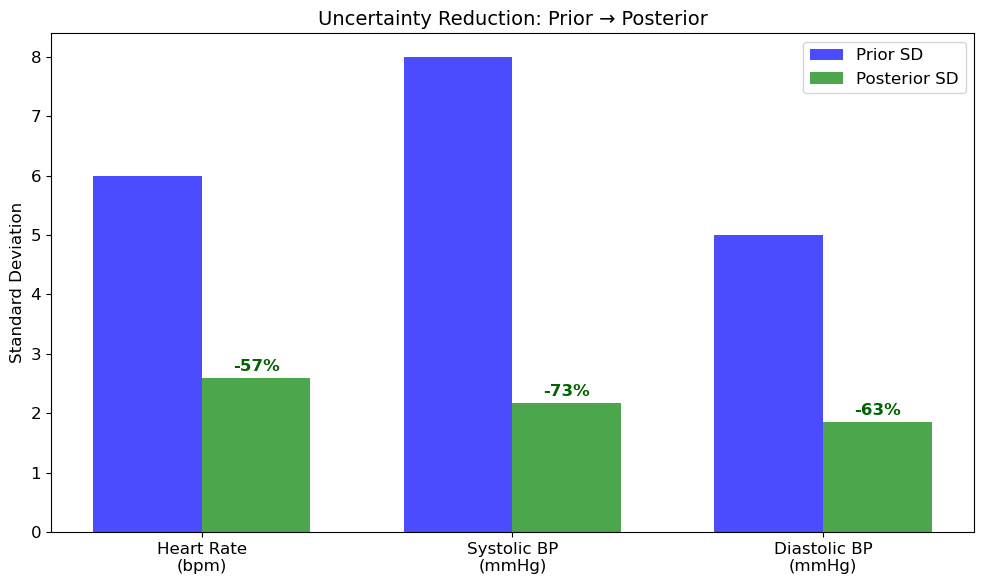

In [11]:
# Visualize uncertainty reduction
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(L)
width = 0.35

bars1 = ax.bar(x - width/2, prior_sd, width, label='Prior SD', color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, post_sd, width, label='Posterior SD', color='green', alpha=0.7)

ax.set_ylabel('Standard Deviation', fontsize=12)
ax.set_title('Uncertainty Reduction: Prior → Posterior', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(['Heart Rate\n(bpm)', 'Systolic BP\n(mmHg)', 'Diastolic BP\n(mmHg)'])
ax.legend()

# Add reduction percentages
for i, (p, q) in enumerate(zip(prior_sd, post_sd)):
    reduction = (1 - q/p) * 100
    ax.annotate(f'-{reduction:.0f}%', xy=(i + width/2, q), 
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=12, color='darkgreen', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. What If W Were Trivial? Comparison

In [12]:
# Compare with a trivial W (identity-like, direct measurements)
# If we could directly measure HR, Sys, Dia with same noise levels

W_trivial = np.array([
    [1.0, 0.0, 0.0],  # Direct HR measurement
    [0.0, 1.0, 0.0],  # Direct Sys measurement
    [0.0, 0.0, 1.0],  # Direct Dia measurement
])

# Use average noise level from our derived metrics
avg_noise = np.mean(np.diag(Sigma_y)[:3])
Sigma_y_trivial = np.eye(3) * avg_noise
b_trivial = np.zeros(3)

# Generate observations with trivial W
y_trivial = W_trivial @ z_true + b_trivial + np.random.multivariate_normal(np.zeros(3), Sigma_y_trivial)

# Bayesian inference with trivial W
mu_post_trivial, Sigma_post_trivial = bayes_rule_gaussian(
    y_trivial, mu_z, Sigma_z, W_trivial, b_trivial, Sigma_y_trivial
)

print("=" * 65)
print("COMPARISON: Non-trivial W vs Trivial W (Identity)")
print("=" * 65)

print("\nNon-trivial W (derived metrics):")
print(f"  Observations: 5 derived quantities (linear combinations)")
print(f"  Posterior SD: HR={np.sqrt(Sigma_post[0,0]):.2f}, Sys={np.sqrt(Sigma_post[1,1]):.2f}, Dia={np.sqrt(Sigma_post[2,2]):.2f}")

print("\nTrivial W (direct measurements):")
print(f"  Observations: 3 direct measurements")
print(f"  Posterior SD: HR={np.sqrt(Sigma_post_trivial[0,0]):.2f}, Sys={np.sqrt(Sigma_post_trivial[1,1]):.2f}, Dia={np.sqrt(Sigma_post_trivial[2,2]):.2f}")

print("\n→ The non-trivial W with 5 observations provides more information")
print("  than 3 direct measurements with similar noise levels!")

COMPARISON: Non-trivial W vs Trivial W (Identity)

Non-trivial W (derived metrics):
  Observations: 5 derived quantities (linear combinations)
  Posterior SD: HR=2.60, Sys=2.17, Dia=1.85

Trivial W (direct measurements):
  Observations: 3 direct measurements
  Posterior SD: HR=3.06, Sys=3.10, Dia=2.54

→ The non-trivial W with 5 observations provides more information
  than 3 direct measurements with similar noise levels!


## 9. Sequential Monitoring Over Time

In [13]:
# Simulate monitoring over multiple workout sessions
n_sessions = 10

# True state evolves: athlete gets fitter (lower resting HR, better BP)
z_true_trajectory = np.array([
    [60 - 0.5*t, 120 - 0.3*t, 75 - 0.2*t] for t in range(n_sessions)
])

# Store tracking results
mu_trajectory = [mu_z.copy()]
Sigma_trajectory = [Sigma_z.copy()]

mu_current = mu_z.copy()
Sigma_current = Sigma_z.copy()

print("=" * 75)
print("SEQUENTIAL MONITORING: Tracking Fitness Progress")
print("=" * 75)
print(f"{'Session':<8} {'True HR':<8} {'Est HR':<8} {'True Sys':<9} {'Est Sys':<9} {'Error':<8}")
print("-" * 75)

for session in range(n_sessions):
    z_now = z_true_trajectory[session]
    
    # Generate observations
    y_now = W @ z_now + b + np.random.multivariate_normal(np.zeros(D), Sigma_y)
    
    # Bayesian update
    mu_current, Sigma_current = bayes_rule_gaussian(
        y_now, mu_current, Sigma_current, W, b, Sigma_y
    )
    
    mu_trajectory.append(mu_current.copy())
    Sigma_trajectory.append(Sigma_current.copy())
    
    error = np.linalg.norm(mu_current - z_now)
    print(f"{session+1:<8} {z_now[0]:<8.1f} {mu_current[0]:<8.1f} {z_now[1]:<9.1f} {mu_current[1]:<9.1f} {error:<8.2f}")

SEQUENTIAL MONITORING: Tracking Fitness Progress
Session  True HR  Est HR   True Sys  Est Sys   Error   
---------------------------------------------------------------------------
1        60.0     58.4     120.0     120.2     1.85    
2        59.5     56.9     119.7     118.4     3.00    
3        59.0     56.9     119.4     118.7     2.21    
4        58.5     56.2     119.1     118.7     2.38    
5        58.0     57.1     118.8     118.3     1.04    
6        57.5     56.9     118.5     117.7     0.96    
7        57.0     56.6     118.2     117.8     0.55    
8        56.5     56.5     117.9     117.7     0.50    
9        56.0     56.6     117.6     117.4     0.67    
10       55.5     56.3     117.3     117.7     0.96    


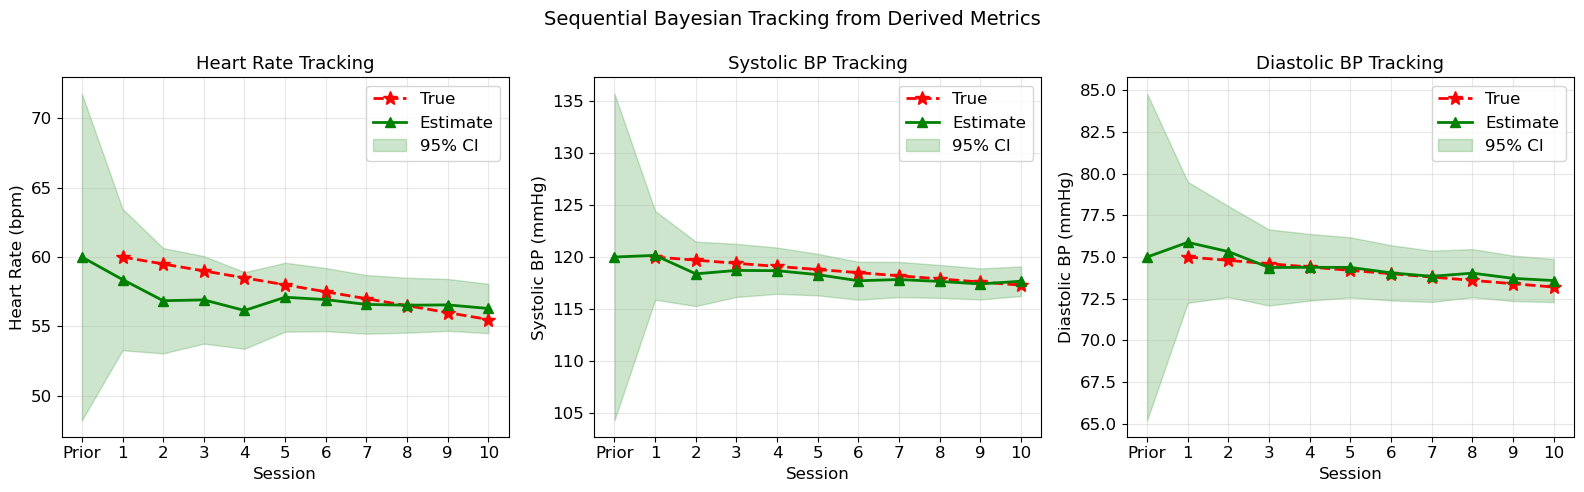

In [14]:
# Visualize tracking
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sessions = np.arange(n_sessions + 1)
mu_traj = np.array(mu_trajectory)

for ax, var_idx, name, unit in zip(axes, [0, 1, 2], 
                                    ['Heart Rate', 'Systolic BP', 'Diastolic BP'],
                                    ['bpm', 'mmHg', 'mmHg']):
    # True values
    ax.plot(sessions[1:], z_true_trajectory[:, var_idx], 'r--', 
            linewidth=2, marker='*', markersize=10, label='True')
    
    # Estimates
    ax.plot(sessions, mu_traj[:, var_idx], 'g-', 
            linewidth=2, marker='^', markersize=7, label='Estimate')
    
    # Uncertainty bands
    sds = np.array([np.sqrt(S[var_idx, var_idx]) for S in Sigma_trajectory])
    ax.fill_between(sessions, mu_traj[:, var_idx] - 1.96*sds, 
                    mu_traj[:, var_idx] + 1.96*sds,
                    alpha=0.2, color='green', label='95% CI')
    
    ax.set_xlabel('Session', fontsize=12)
    ax.set_ylabel(f'{name} ({unit})', fontsize=12)
    ax.set_title(f'{name} Tracking', fontsize=13)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(sessions)
    ax.set_xticklabels(['Prior'] + [str(i) for i in range(1, n_sessions+1)])

plt.suptitle('Sequential Bayesian Tracking from Derived Metrics', fontsize=14)
plt.tight_layout()
plt.show()

## 10. Observability Analysis: Can We Recover All Latent Variables?

In [15]:
# Analyze the observability of the system
# In linear systems, this depends on the rank and condition of W

print("=" * 65)
print("OBSERVABILITY ANALYSIS")
print("=" * 65)

print(f"\nW matrix shape: {W.shape} (D={D} observations, L={L} latents)")
print(f"Rank of W: {np.linalg.matrix_rank(W)}")
print(f"\n→ Full column rank ({L}) means all latent variables are observable!")

# Singular value decomposition
U, S, Vt = np.linalg.svd(W)
print(f"\nSingular values of W: {S}")
print(f"Condition number: {S[0]/S[-1]:.2f}")

# Which observations are most informative?
print("\n" + "-" * 50)
print("Information content per observation (row norm of W):")
for i, name in enumerate(metric_names):
    row_norm = np.linalg.norm(W[i])
    print(f"  {name:<28}: {row_norm:.3f}")

# Fisher information perspective
print("\n" + "-" * 50)
print("Fisher information per observation (W_i^T Σ_y^{-1} W_i diagonal):")
for i, name in enumerate(metric_names):
    fisher_contrib = W[i:i+1].T @ np.array([[1/Sigma_y[i,i]]]) @ W[i:i+1]
    print(f"  {name:<28}: {np.trace(fisher_contrib):.4f}")

OBSERVABILITY ANALYSIS

W matrix shape: (5, 3) (D=5 observations, L=3 latents)
Rank of W: 3

→ Full column rank (3) means all latent variables are observable!

Singular values of W: [1.7147311  1.22939244 1.04510624]
Condition number: 1.64

--------------------------------------------------
Information content per observation (row norm of W):
  Pulse Pressure              : 1.414
  Mean Arterial Pressure      : 0.745
  Rate-Pressure Product       : 1.399
  Cardiac Output Index        : 0.510
  Vascular Resistance         : 0.877

--------------------------------------------------
Fisher information per observation (W_i^T Σ_y^{-1} W_i diagonal):
  Pulse Pressure              : 0.2222
  Mean Arterial Pressure      : 0.1389
  Rate-Pressure Product       : 0.0783
  Cardiac Output Index        : 0.0650
  Vascular Resistance         : 0.0481


## Summary

This notebook demonstrated **Bayes Rule for Gaussians** (Chapter 3.3.1) with a **non-trivial W matrix** representing derived health metrics:

### Key Differences from Identity W:

| Identity W (Direct Measurements) | Non-Trivial W (Derived Metrics) |
|----------------------------------|----------------------------------|
| Each observation measures one variable | Each observation is a linear combination |
| W is sparse (ones on diagonal) | W is dense with meaningful coefficients |
| Information flows directly | Information flows through mixing |
| Can have fewer observations | Can have more observations than latents |

### Mathematical Insights:

1. **Information aggregation through W**: The term $\mathbf{W}^T \boldsymbol{\Sigma}_y^{-1} \mathbf{W}$ shows how observations combine to inform the latent state

2. **Observability**: If W has full column rank, all latent variables can be recovered (in principle)

3. **Redundancy can help**: More observations (D > L) provide additional information through different linear combinations

4. **Correlation structure changes**: The posterior correlation differs from the prior due to the coupling induced by W

### Practical Applications:

- **Sensor fusion**: Combining multiple indirect measurements
- **Medical diagnostics**: Inferring underlying conditions from biomarkers
- **Financial modeling**: Inferring latent factors from asset returns
- **Recommendation systems**: Inferring user preferences from behavior